# Plot fMRI task-state benchmark

Configure the data split, ranks, and models below, then run all cells. The figure uses vertical subject-level NMI boxplots, keeps ranks of the same model together, and colors models by their representation space using the same palette as the synthetic benchmark notebook.

In [25]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## Plot settings

Use `None` to include every available rank or model. Models that are requested but unavailable in the result file are skipped.

In [26]:
RANKS = None                 # Example: [1, 5, 10, 25, 50]
MODELS = None                # Example: ["Wrapped normal", "Complex ACG"]

# Works whether Jupyter starts in the repository root or in overview_paper.
OVERVIEW_DIR = Path("overview_paper") if Path("overview_paper").is_dir() else Path(".")
RESULTS_DIR = OVERVIEW_DIR / "fmri_task_results"
RESULTS_PATH = RESULTS_DIR / "fmri_task_state_nmi.csv"

SAVE_FIGURE = True
OUTPUT_PATH = RESULTS_DIR / "fmri_task_state_nmi_boxplot.png"
DPI = 300
FIGURE_WIDTH = 7.2
BOX_STEP = 0.68
MODEL_GAP = 0.20
SPACE_GAP = 1.7

In [27]:
# Match the manifold colors in plot_synthetic_phase_mixture_benchmark.ipynb.
# Complex Euclidean space is specific to this benchmark and therefore gets
# a distinct dark gray; it is not the complex-projective Complex Gaussian
# representation used in the synthetic benchmark.
SPACE_COLORS = {
    "Quotient torus": "#F4A261",
    "Complex projective space": "#2A9D8F",
    "PSD space": "#D65DB1",
    "Grassmann manifold": "#8E6CBE",
    "Real projective space": "#457B9D",
    "Complex Euclidean space": "#292929",
    "Euclidean space": "#4D4D4D",
}

SPACE_LABELS = {
    "Quotient torus": "Instantaneous phase",
    "Complex projective space": "Instantaneous phase",
    "PSD space": "Cosine-coherence matrix",
    "Grassmann manifold": "Cosine-coherence subspace",
    "Real projective space": "Leading cosine-coherence eigenvector",
    "Complex Euclidean space": "Analytic signal",
    "Euclidean space": "fMRI time series",
}

# Dict insertion order is the requested representation-space order and also
# determines model order within each space.
SPACE_MODELS = {
    "Quotient torus": [
        "UMVM", "Quotient torus K-means",
    ],
    "Complex projective space": [
        "Complex Watson", "Complex ACG", "Complex Bingham",
        "Complex diametrical K-means",
    ],
    "PSD space": [
        "Singular Wishart", "Weighted Grassmann K-means",
    ],
    "Grassmann manifold": [
        "MACG", "Grassmann K-means",
    ],
    "Real projective space": [
        "Watson", "ACG", "Diametrical K-means","Least-squares K-means", 
    ],
    "Complex Euclidean space": [
        "Complex Normal",
    ],
    "Euclidean space": [
        "Normal",
    ],
}

MODEL_SPACE = {
    model: space
    for space, models in SPACE_MODELS.items()
    for model in models
}
MODEL_ORDER = [model for models in SPACE_MODELS.values() for model in models]

In [28]:
def load_results():
    results = pd.read_csv(RESULTS_PATH)
    # Normalize legacy result labels to the terminology used in the paper.
    results["model"] = results["model"].replace({"VMVM": "UMVM"})
    required = {"model", "rank", "set", "subject", "NMI"}
    missing = required.difference(results.columns)
    if missing:
        raise ValueError(f"Missing columns in {RESULTS_PATH.name}: {sorted(missing)}")

    # This figure is strictly out-of-sample: training subjects are never plotted.
    frame = results.loc[results["set"] == "test"].copy()
    if frame.empty:
        raise ValueError("No rows found for set='test'")

    unknown = sorted(set(frame["model"]) - set(MODEL_SPACE))
    if unknown:
        print(f"Skipping models without a representation-space style: {unknown}")
        frame = frame.loc[frame["model"].isin(MODEL_SPACE)].copy()

    if MODELS is not None:
        unavailable = [model for model in MODELS if model not in set(frame["model"])]
        if unavailable:
            print(f"Skipping unavailable models: {unavailable}")
        frame = frame.loc[frame["model"].isin(MODELS)].copy()

    if RANKS is not None:
        # Unranked methods remain visible; the rank filter applies only to
        # methods whose model specification has a rank.
        frame = frame.loc[frame["rank"].isna() | frame["rank"].isin(RANKS)].copy()

    if frame.empty:
        raise ValueError("No rows remain after applying the plot settings")
    return frame


def display_label(model, rank, number_of_ranks):
    if pd.isna(rank) or number_of_ranks <= 1:
        return model
    return f"{model} (rank {int(rank)})"


def ordered_boxes(frame):
    """Return adjacent model/rank boxes in representation-space order."""
    boxes = []
    for model in MODEL_ORDER:
        model_rows = frame.loc[frame["model"] == model]
        if model_rows.empty:
            continue
        ranks = sorted(model_rows["rank"].dropna().unique())
        if ranks:
            boxes.extend((model, rank) for rank in ranks)
        if model_rows["rank"].isna().any():
            boxes.append((model, np.nan))
    return boxes

In [29]:
def plot_boxplots(frame):
    """Plot horizontally oriented boxes in vertically stacked model groups."""
    boxes = ordered_boxes(frame)
    positions, values, colors, tick_labels, line_styles = [], [], [], [], []
    space_spans = []

    position = 1.0
    previous_space = None
    space_start = None
    for model in MODEL_ORDER:
        model_boxes = [(m, r) for m, r in boxes if m == model]
        if not model_boxes:
            continue

        space = MODEL_SPACE[model]
        if space != previous_space:
            if previous_space is not None:
                space_spans.append((previous_space, space_start, positions[-1]))
                position += SPACE_GAP
            space_start = position

        number_of_ranks = sum(not pd.isna(rank) for _, rank in model_boxes)
        for _, rank in model_boxes:
            if pd.isna(rank):
                selected = frame.loc[(frame["model"] == model) & frame["rank"].isna(), "NMI"]
            else:
                selected = frame.loc[(frame["model"] == model) & (frame["rank"] == rank), "NMI"]
            positions.append(position)
            values.append(selected.dropna().to_numpy())
            colors.append(SPACE_COLORS[space])
            tick_labels.append(display_label(model, rank, number_of_ranks))
            line_styles.append("--" if "K-means" in model else "-")
            position += BOX_STEP

        position += MODEL_GAP
        previous_space = space

    space_spans.append((previous_space, space_start, positions[-1]))
    height = max(4.8, 0.235 * position + 0.70)
    sns.set_theme(style="whitegrid", context="paper", font_scale=0.9)
    fig, ax = plt.subplots(figsize=(FIGURE_WIDTH, height))
    artists = ax.boxplot(
        values, positions=positions, widths=0.52, vert=False, patch_artist=True,
        showfliers=True,
        medianprops={"color": "#222222", "linewidth": 1.15},
        whiskerprops={"color": "#666666", "linewidth": 0.8},
        capprops={"color": "#666666", "linewidth": 0.8},
        flierprops={"marker": "o", "markersize": 2.5, "markerfacecolor": "#777777",
                    "markeredgewidth": 0, "alpha": 0.55},
    )

    # Matplotlib returns two whiskers and two caps per box. Apply the same
    # dashed grammar as the reference notebook to every K-means box line.
    for i, (patch, color, style) in enumerate(zip(artists["boxes"], colors, line_styles)):
        patch.set(facecolor=color, edgecolor=color, alpha=0.72,
                  linewidth=1.0, linestyle=style)
        artists["medians"][i].set_linestyle(style)
        for line in artists["whiskers"][2 * i:2 * i + 2] + artists["caps"][2 * i:2 * i + 2]:
            line.set_linestyle(style)

    ax.set_yticks(positions, tick_labels, fontsize=7.6)
    ax.invert_yaxis()
    ax.set_xlabel("Normalized mutual information (NMI)")
    ax.set_ylabel("")
    ax.set_xlim(-0.01, 0.705)
    ax.grid(axis="x", color="0.88", linewidth=0.65)
    ax.grid(axis="y", visible=False)

    # Subtle bands and compact descriptors make sample-space groups easier
    # to scan without adding a separate legend.
    for i, (space, start, end) in enumerate(space_spans):
        ax.axhspan(start - 1.02, end + 0.38, color=SPACE_COLORS[space],
                   alpha=0.035 if i % 2 == 0 else 0.018, zorder=0)
        ax.text(-0.035, start - 0.91, space,
                transform=ax.get_yaxis_transform(), ha="right", va="bottom",
                fontsize=7.8, fontweight="semibold", color="#2B2B2B",
                clip_on=False)
        ax.text(-0.035, start - 0.44, SPACE_LABELS[space],
                transform=ax.get_yaxis_transform(), ha="right", va="bottom",
                fontsize=6.9, fontstyle="italic", color="#666666",
                clip_on=False)

    sns.despine(ax=ax)
    ax.set_title("fMRI task–state overlap", loc="center", fontsize=10.5,
                 fontweight="semibold", pad=19)
    ax.text(0.5, 1.008, "Subject-level NMI distributions · 100 held-out subjects",
            transform=ax.transAxes, ha="center", va="bottom", fontsize=7.4,
            color="#666666")
    fig.subplots_adjust(left=0.48, right=0.98, bottom=0.10, top=0.91)
    return fig, ax

Skipping models without a representation-space style: ['Wrapped normal']
Saved fmri_task_state_nmi_boxplot.png


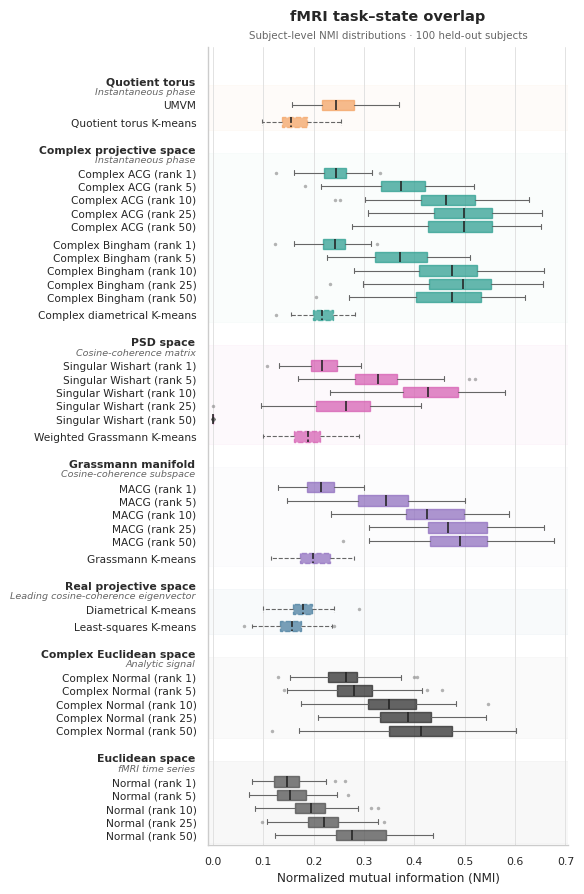

In [30]:
results = load_results()
figure, axis = plot_boxplots(results)

if SAVE_FIGURE:
    OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
    figure.savefig(OUTPUT_PATH, dpi=DPI, bbox_inches="tight")
    print(f"Saved {OUTPUT_PATH.name}")

plt.show()